# CPSC 393 Final Project
- Dr. Rajeev Joshi
- Ethan E. Lopez
- Greyson Chavez
- Khalid Al Mahmoud

## **Stage 1: Data Exploration**
- **Apple Watch & Fitbit Data**

To run this code properly, the dataset must be downloaded or accessible in your local files/directory.

In [1]:
# import the necessary modules
import numpy as np
import pandas as pd

# silence warnings from sklearn
import warnings
warnings.simplefilter("ignore")

# libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model using statsmodels
import statsmodels.api as sm

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn import metrics

In [2]:
# read in the fitbit data
data = pd.read_csv("aw_fb_data.csv")
data.head()

,Unnamed: 0,X1,age,gender,height,weight,steps,hear_rate,calories,distance,entropy_heart,entropy_setps,resting_heart,corr_heart_steps,norm_heart,intensity_karvonen,sd_norm_heart,steps_times_distance,device,activity
0,1,1,20,1,168.0,65.4,10.771429,78.531302,0.344533,0.008327,6.221612,6.116349,59.0,1.000000,19.531302,0.138520,1.000000,0.089692,apple watch,Lying
1,2,2,20,1,168.0,65.4,11.475325,78.453390,3.287625,0.008896,6.221612,6.116349,59.0,1.000000,19.453390,0.137967,1.000000,0.102088,apple watch,Lying
2,3,3,20,1,168.0,65.4,12.179221,78.540825,9.484000,0.009466,6.221612,6.116349,59.0,1.000000,19.540825,0.138587,1.000000,0.115287,apple watch,Lying
3,4,4,20,1,168.0,65.4,12.883117,78.628260,10.154556,0.010035,6.221612,6.116349,59.0,1.000000,19.628260,0.139208,1.000000,0.129286,apple watch,Lying
4,5,5,20,1,168.0,65.4,13.587013,78.715695,10.825111,0.010605,6.221612,6.116349,59.0,0.982816,19.715695,0.139828,0.241567,0.144088,apple watch,Lying


In [3]:
data.shape # compute shape (rows x columns)

(6264, 20)

6264 rows x 20 columns

In [4]:
data.info() # get data info (null counts, data types, and more)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6264 entries, 0 to 6263
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            6264 non-null   int64  
 1   X1                    6264 non-null   int64  
 2   age                   6264 non-null   int64  
 3   gender                6264 non-null   int64  
 4   height                6264 non-null   float64
 5   weight                6264 non-null   float64
 6   steps                 6264 non-null   float64
 7   hear_rate             6264 non-null   float64
 8   calories              6264 non-null   float64
 9   distance              6264 non-null   float64
 10  entropy_heart         6264 non-null   float64
 11  entropy_setps         6264 non-null   float64
 12  resting_heart         6264 non-null   float64
 13  corr_heart_steps      6264 non-null   float64
 14  norm_heart            6264 non-null   float64
 15  intensity_karvonen   

### 18 numerical variables
- 4 integers
- 14 floats
- 2 identifiers

### 2 categorical variables
- 2 object types


## Data Preprocessing Methods

### Step 1: Remove Indentifiers
- these don't contribute to valuable model coefficients

In [5]:
# drop columns unnamed and x1
data = data.drop(columns=['Unnamed: 0', 'X1'])

In [6]:
data.shape # data shape

(6264, 18)

### Step 2: Check For Nulls & Duplicates

In [7]:
# explore nulls if any
null_counts = data.isnull().sum() # sum nulls for each column
print("Number of null values per column:")
print(null_counts) # show counts

Number of null values per column:
age                     0
gender                  0
height                  0
weight                  0
steps                   0
hear_rate               0
calories                0
distance                0
entropy_heart           0
entropy_setps           0
resting_heart           0
corr_heart_steps        0
norm_heart              0
intensity_karvonen      0
sd_norm_heart           0
steps_times_distance    0
device                  0
activity                0
dtype: int64


In [8]:
# count duplicate rows
duplicates = data.duplicated().sum() # count duplicates
print(f"Number of duplicate rows in the dataset: {duplicates}")

Number of duplicate rows in the dataset: 10


In [9]:
data = data.drop_duplicates() # drop duplicates in the data
data.shape # print new data shape

(6254, 18)

### Step 3: Explore Numerical Distributions
- Do all inputs make sense?

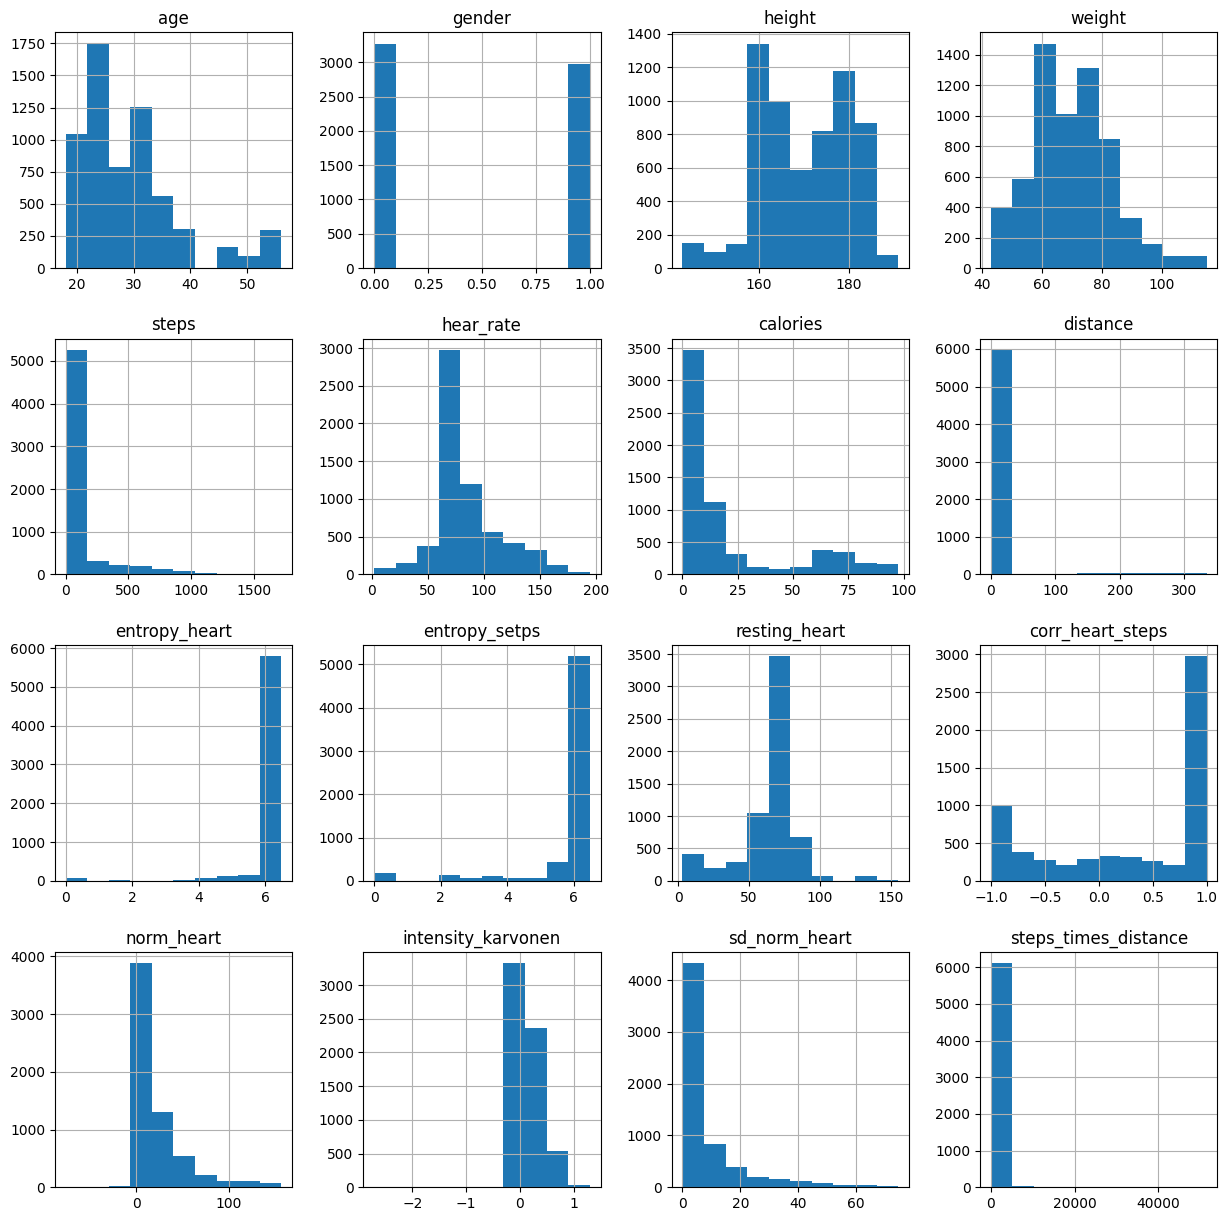

In [10]:
data.select_dtypes(include='number').hist(figsize=(15, 15)) # select numerical histogram distributions
plt.show() # show histograms

In [11]:
data.describe() # get descriptive stats for all valid variables

,age,gender,height,weight,steps,hear_rate,calories,distance,entropy_heart,entropy_setps,resting_heart,corr_heart_steps,norm_heart,intensity_karvonen,sd_norm_heart,steps_times_distance
count,6254.000000,6254.000000,6254.000000,6254.000000,6254.000000,6254.000000,6254.000000,6254.000000,6254.000000,6254.000000,6254.000000,6254.000000,6254.000000,6254.000000,6254.000000,6254.000000
mean,29.146946,0.476175,169.704893,69.585465,109.735856,86.167663,19.460825,13.853074,6.039775,5.749111,65.862855,0.305338,20.304808,0.155728,8.097732,590.977092
std,8.897986,0.499472,10.323433,13.428728,222.933653,28.549725,27.311334,45.975290,0.728654,1.236422,21.064230,0.775541,28.399219,0.211003,12.534308,4067.018419
min,18.000000,0.000000,143.000000,43.000000,1.000000,2.222222,0.056269,0.000440,0.000000,0.000000,3.000000,-1.000000,-76.000000,-2.714286,0.000000,0.000690
25%,23.000000,0.000000,160.000000,60.000000,5.166667,75.598079,0.735125,0.019079,6.108524,5.909440,58.134333,-0.467770,1.155692,0.009933,0.264722,0.653927
50%,28.000000,0.000000,168.000000,68.000000,10.100354,77.268372,4.000000,0.178970,6.189825,6.168980,75.000000,0.661935,9.937344,0.079938,2.893503,13.494912
75%,33.000000,1.000000,180.000000,77.300000,106.000000,95.663793,20.500000,15.697368,6.247928,6.247928,76.138701,1.000000,27.111099,0.212083,9.660782,93.747841
max,56.000000,1.000000,191.000000,115.000000,1714.000000,194.333333,97.500000,335.000000,6.475733,6.475733,155.000000,1.000000,156.319444,1.297980,74.457929,51520.000000


### Evaluation For All Variables

#### `age`, `gender`, `height`
*  These are standard demographic variables.
    *   `age`: Age of the participant in years. (Range 18-56, mean ~29).
    *   `gender`: Binary categorical variable (0 for one gender and 1 for another)
        * Mean is 0.48 -> fairly even split
    *   `height`: Height of the participant in centimeters (cm) given the values (Range 143-191 cm).

**These are good.**


#### `weight`
*   Weight of the participant in **kilograms (kg)**.
    *   Range: 43 kg to 115 kg (approx. 95 lbs to 253 lbs)
    * We decided to leave this in kg. for original data consistency

**This is good.**

#### `steps`, `calories`, `distance`
*   These are typical fitness tracking metrics.
    *   `steps`: Number of steps taken (max 1714 is reasonable)
    *   `calories`: Calories burned (min 0.05, max 97.5 -> also reasonable)
    *   `distance`: Distance covered (max 335.0) in meters (reasonable)

**These are good.**

#### `hear_rate` and `resting_heart`
*   These variables measure heart rate.
    *   `hear_rate`: Instantaneous or average heart rate during activity.
        * minimum of 2.22 bpm!
        * typical heart rates range from 40-200 bpm during activity
        * this data has errors
    *   `resting_heart`: Resting heart rate.
        * a minimum of 3.0 bpm is unrealistic.
        
**Values outside possible ranges will be considered outliers and either removed or imputed.**


#### `entropy_heart`, `entropy_setps`, `corr_heart_steps`, `sd_norm_heart`

*   These are derived features of variability and relationship between heart rate and steps.
    *   `entropy_heart`: Entropy of heart rate, used as a measure of heart rate variability. (0-7)
    *   `entropy_setps`: Entropy of steps for variability in stepping patterns. (0-7)
    *   `corr_heart_steps`: Correlation between heart rate and steps. (-1 to 1)
    *   `sd_norm_heart`: Standard deviation of normalized heart rate. (0-75)

**These ranges are valid.**


#### `norm_heart`, `intensity_karvonen`
*   **Interpretation:**
    *   `norm_heart`: Normalized heart rate.
        * minimum of -76 is problematic
        * normalization produced negative values outside of a typical range of 0-1 or -1 to 1.
    *   `intensity_karvonen`: refers to exercise intensity calculated using the Karvonen formula, using resting heart rate and maximum heart rate to determine target zones.
        * (min -2.71, max 1.29)
        * suggests ratios where negative values are unusual but could represent very low intensity.

**More investigation should be done for these variables if we decide to include them in the study.**


#### `steps_times_distance`
*   `steps` multiplied by `distance`, representing an overall measure of movement (0.0006 - 51520)

**This range is valid.**


#### `device`, `activity`
*   These are categorical variables for the tracking device and the activity performed.
    *   `device`: The type of wearable device used (e.g., 'apple watch', 'fitbit').
    *   `activity`: The specific activity being tracked (e.g., 'Lying', 'Running 7 METs'). These will be important for activity recognition or analysis.

**Convert to category types through one-hot encoding.**

## **Stage 2: Data Cleaning**

### Step 1: Correct Spelling Errors

In [12]:
data = data.rename(columns={'hear_rate': 'heart_rate', 'entropy_setps': 'entropy_steps'}) # correct spelling erros in original data labels
data.head()

,age,gender,height,weight,steps,heart_rate,calories,distance,entropy_heart,entropy_steps,resting_heart,corr_heart_steps,norm_heart,intensity_karvonen,sd_norm_heart,steps_times_distance,device,activity
0,20,1,168.0,65.4,10.771429,78.531302,0.344533,0.008327,6.221612,6.116349,59.0,1.000000,19.531302,0.138520,1.000000,0.089692,apple watch,Lying
1,20,1,168.0,65.4,11.475325,78.453390,3.287625,0.008896,6.221612,6.116349,59.0,1.000000,19.453390,0.137967,1.000000,0.102088,apple watch,Lying
2,20,1,168.0,65.4,12.179221,78.540825,9.484000,0.009466,6.221612,6.116349,59.0,1.000000,19.540825,0.138587,1.000000,0.115287,apple watch,Lying
3,20,1,168.0,65.4,12.883117,78.628260,10.154556,0.010035,6.221612,6.116349,59.0,1.000000,19.628260,0.139208,1.000000,0.129286,apple watch,Lying
4,20,1,168.0,65.4,13.587013,78.715695,10.825111,0.010605,6.221612,6.116349,59.0,0.982816,19.715695,0.139828,0.241567,0.144088,apple watch,Lying


### Step 2: Address High Multicollinearity
- if variables have extreme multicollinearity, this makes them less interpretable
- drop regardless if their ranges make sense or not

In [13]:
data.select_dtypes(include='number').corr() # show correlation coefficients for numerical variables

,age,gender,height,weight,steps,heart_rate,calories,distance,entropy_heart,entropy_steps,resting_heart,corr_heart_steps,norm_heart,intensity_karvonen,sd_norm_heart,steps_times_distance
age,1.000000,-0.236256,-0.519003,-0.154313,0.007043,-0.009661,-0.065802,-0.060933,0.008153,0.004485,-0.026943,0.067125,0.010272,0.072434,0.058310,-0.045721
gender,-0.236256,1.000000,0.735585,0.580259,-0.069441,-0.094743,0.071602,-0.051625,-0.048119,0.018151,-0.084672,-0.040668,-0.032442,-0.063945,-0.059534,0.022379
height,-0.519003,0.735585,1.000000,0.693942,0.025954,-0.124593,0.034005,-0.091399,-0.070064,0.051797,-0.029541,-0.031702,-0.103342,-0.124433,-0.092209,-0.075768
weight,-0.154313,0.580259,0.693942,1.000000,0.046566,-0.066378,-0.025571,-0.071878,-0.147533,-0.043996,-0.018771,-0.066890,-0.052807,-0.063542,-0.012354,-0.008374
steps,0.007043,-0.069441,0.025954,0.046566,1.000000,0.164381,-0.251010,-0.090673,0.016361,0.084278,0.084765,-0.228655,0.102380,0.143727,0.113115,0.023690
heart_rate,-0.009661,-0.094743,-0.124593,-0.066378,0.164381,1.000000,-0.145045,-0.069425,0.056723,0.033319,0.376031,-0.174194,0.726391,0.783487,0.281326,0.064907
calories,-0.065802,0.071602,0.034005,-0.025571,-0.251010,-0.145045,1.000000,0.255463,0.004457,-0.105723,-0.059748,0.207982,-0.101498,-0.164896,-0.148911,0.120058
distance,-0.060933,-0.051625,-0.091399,-0.071878,-0.090673,-0.069425,0.255463,1.000000,-0.062970,-0.303851,-0.323089,0.081811,0.169848,0.065806,0.297148,0.653982
entropy_heart,0.008153,-0.048119,-0.070064,-0.147533,0.016361,0.056723,0.004457,-0.062970,1.000000,0.677454,0.105774,-0.057280,-0.021431,0.038076,-0.271871,-0.076328
entropy_steps,0.004485,0.018151,0.051797,-0.043996,0.084278,0.033319,-0.105723,-0.303851,0.677454,1.000000,0.361965,-0.069067,-0.234981,-0.129900,-0.428191,-0.272042


#### Build Correlation Heatmap For Better Visualization

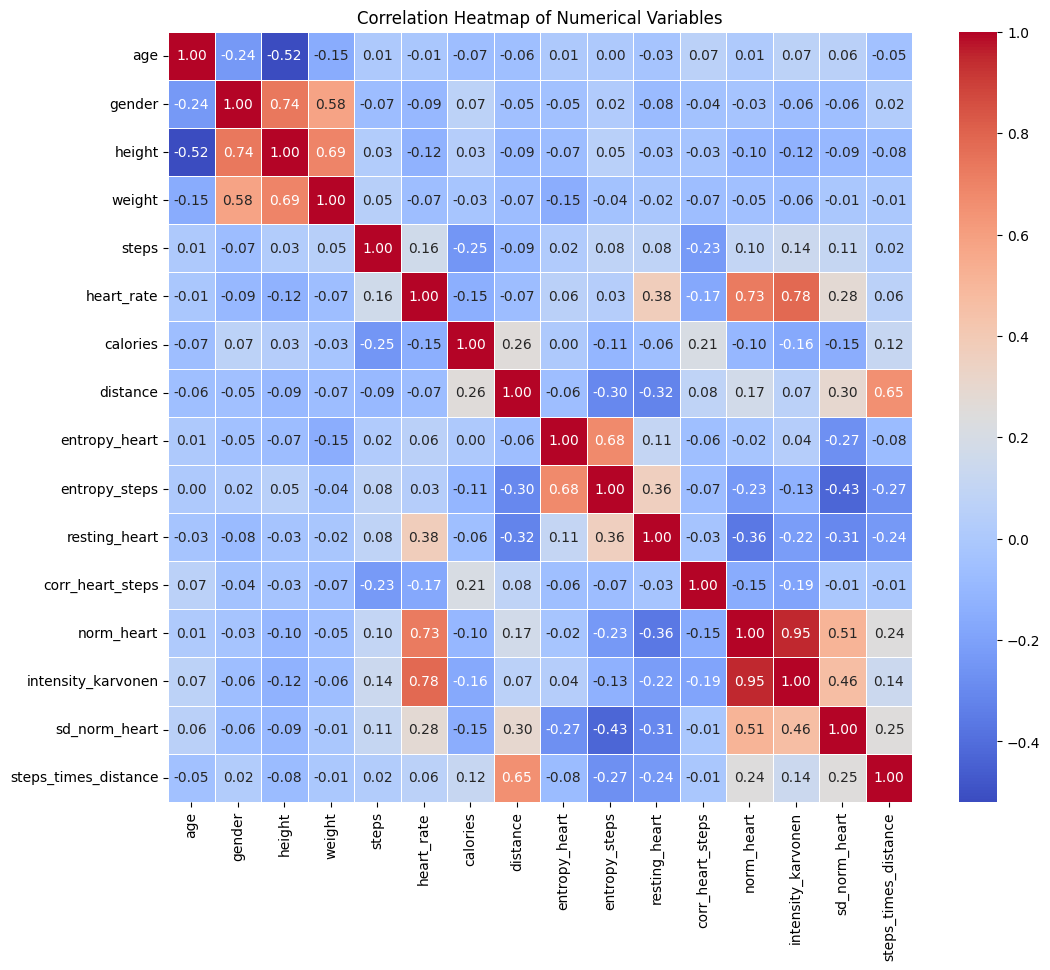

In [14]:
plt.figure(figsize=(12, 10)) # plot size
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5) # create heatmap with numerical data types
# label coefficients, use a coolwarm theme, and limit to 2 decimal places
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

# Our Guidelines
- **any variable combinations above 0.75 correlation should be flagged**
- these include:

1. intensity_karvonen and norm_heart
2. intensity_karvonen and heart_rate

In [15]:
corr_nh_ik = data['norm_heart'].corr(data['intensity_karvonen']) # grab correlation coefficient for norm_heart and intensity_karvonen
print(f"Correlation between 'intensity_karvonen' and 'norm_heart': {corr_nh_ik:.4f}") # print with 4 decimals

Correlation between 'intensity_karvonen' and 'norm_heart': 0.9506


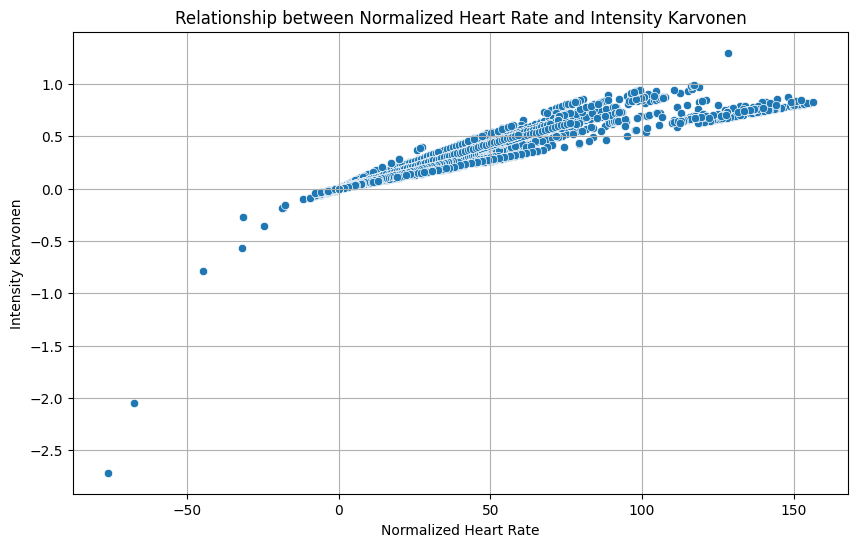

In [16]:
# understand high correlation visually

plt.figure(figsize=(10, 6)) # create plot
sns.scatterplot(x='norm_heart', y='intensity_karvonen', data=data) # plot norm_heart vs. intensity_karvonen
plt.title('Relationship between Normalized Heart Rate and Intensity Karvonen')
plt.xlabel('Normalized Heart Rate')
plt.ylabel('Intensity Karvonen')
plt.grid(True) # show grid
plt.show()

In [17]:
corr_hr_ik = data['heart_rate'].corr(data['intensity_karvonen']) # get correlation coefficient for heart_rate and intensity_karvonen
print(f"Correlation between 'intensity_karvonen' and 'heart_rate': {corr_hr_ik:.4f}") # print with 4 decimals

Correlation between 'intensity_karvonen' and 'heart_rate': 0.7835


Though less cause for alarm, norm_heart also has a high correlation with heart_rate

In [18]:
corr_hr_nh = data['heart_rate'].corr(data['norm_heart']) # get correlation coefficient for norm_heart and intensity_karvonen
print(f"Correlation between 'heart_rate' and 'norm_heart': {corr_hr_nh:.4f}") # print with 4 decimals

Correlation between 'heart_rate' and 'norm_heart': 0.7264


Drop both values to keep unique data contributions

In [19]:
data = data.drop(columns=['norm_heart', 'intensity_karvonen']) # drop norm_heart and intensity_karvonen due to unstable values and high multicollinearity

In [20]:
data.shape # identify shape

(6254, 16)

### Step 3: Drop and Impute Nonsensical Values
- **Goal: Keep data loss under 5%**

#### Listwise Deletion of Heart_rate
- All heart rates under 40 bpm are not possible and should not be included in the dataset

In [21]:
# explore how many unrealistic heart rates there are
hr_under_40_bpm = data[data['heart_rate'] < 40].shape[0] # grabs rows
print(f"Heart Rates Under 40 bpm -> {hr_under_40_bpm} rows or {(hr_under_40_bpm/6254)*100:.2f}% of our current data") # print percentage to 2 decimals

Heart Rates Under 40 bpm -> 231 rows or 3.69% of our current data


In [22]:
data = data[data['heart_rate'] >= 40] # remove rows with heart rates under 40
data.shape # identify new shape

(6023, 16)

#### Median Imputation of resting_heart
- Listwise deletion not applied to keep data under 5% loss
- Done by activity to ensure reasonable values are applied

In [23]:
# count how many rows are less than 40bpm
print(f"\nTotal Rows For 'resting_heart' values < 40 bpm: {data[data['resting_heart'] < 40].shape[0]}")
print()

# median imputation by 'activity' class label
for activity in data['activity'].unique():
    # calculate the median 'resting_heart' for each activity class
    # considering only values >= 40 bpm, get the median
    class_med = data[(data['activity'] == activity) & (data['resting_heart'] >= 40)]['resting_heart'].median()

    # if the calculated median itself is less than 40, assign 40 as the imputation value
    if class_med < 40:
        impute_value = 40.0
    else:
        impute_value = class_med

    # impute values less than 40 bpm within this activity class
    data.loc[(data['activity'] == activity) & (data['resting_heart'] < 40), 'resting_heart'] = impute_value

    print(f"Activity: {activity} -> Imputed By {impute_value:.4f}")


# verify that there are no more values below 40 bpm
print(f"\nTotal Rows For 'resting_heart' values < 40 bpm now: {data[data['resting_heart'] < 40].shape[0]}")


Total Rows For 'resting_heart' values < 40 bpm: 531

Activity: Lying -> Imputed By 75.6670
Activity: Sitting -> Imputed By 75.6675
Activity: Self Pace walk -> Imputed By 75.6670
Activity: Running 3 METs -> Imputed By 75.6679
Activity: Running 5 METs -> Imputed By 75.6670
Activity: Running 7 METs -> Imputed By 75.6670

Total Rows For 'resting_heart' values < 40 bpm now: 0


### Step 4: One-Hot Encode Categorical Columns
- Gender
- Device

#### Encode Gender -> Male and Female

In [24]:
data = pd.get_dummies(data, columns=['gender'], prefix='gender', drop_first=False) # gets dummies with pandas and ensures both new columns are kept
# convert boolean columns to integer (0 or 1)
if 'gender_0' in data.columns: # if 0 is in gender
    data['gender_0'] = data['gender_0'].astype(int) # assign this value to gender_0
if 'gender_1' in data.columns: # if 1 is in gender
    data['gender_1'] = data['gender_1'].astype(int) # assign this value to gender_1
data.head()

,age,height,weight,steps,heart_rate,calories,distance,entropy_heart,entropy_steps,resting_heart,corr_heart_steps,sd_norm_heart,steps_times_distance,device,activity,gender_0,gender_1
0,20,168.0,65.4,10.771429,78.531302,0.344533,0.008327,6.221612,6.116349,59.0,1.000000,1.000000,0.089692,apple watch,Lying,0,1
1,20,168.0,65.4,11.475325,78.453390,3.287625,0.008896,6.221612,6.116349,59.0,1.000000,1.000000,0.102088,apple watch,Lying,0,1
2,20,168.0,65.4,12.179221,78.540825,9.484000,0.009466,6.221612,6.116349,59.0,1.000000,1.000000,0.115287,apple watch,Lying,0,1
3,20,168.0,65.4,12.883117,78.628260,10.154556,0.010035,6.221612,6.116349,59.0,1.000000,1.000000,0.129286,apple watch,Lying,0,1
4,20,168.0,65.4,13.587013,78.715695,10.825111,0.010605,6.221612,6.116349,59.0,0.982816,0.241567,0.144088,apple watch,Lying,0,1


#### Encode Device -> Apple Watch and Fitbit

In [25]:
data = pd.get_dummies(data, columns=['device'], drop_first=False) # get dummies for the device column and keep columns
# convert boolean columns to integer (0 or 1)
for col in ['device_apple watch', 'device_fitbit']: # for both devices
    if col in data.columns:
        data[col] = data[col].astype(int) # grab 1s and 0s and create a new column
data.head() # show new data head

,age,height,weight,steps,heart_rate,calories,distance,entropy_heart,entropy_steps,resting_heart,corr_heart_steps,sd_norm_heart,steps_times_distance,activity,gender_0,gender_1,device_apple watch,device_fitbit
0,20,168.0,65.4,10.771429,78.531302,0.344533,0.008327,6.221612,6.116349,59.0,1.000000,1.000000,0.089692,Lying,0,1,1,0
1,20,168.0,65.4,11.475325,78.453390,3.287625,0.008896,6.221612,6.116349,59.0,1.000000,1.000000,0.102088,Lying,0,1,1,0
2,20,168.0,65.4,12.179221,78.540825,9.484000,0.009466,6.221612,6.116349,59.0,1.000000,1.000000,0.115287,Lying,0,1,1,0
3,20,168.0,65.4,12.883117,78.628260,10.154556,0.010035,6.221612,6.116349,59.0,1.000000,1.000000,0.129286,Lying,0,1,1,0
4,20,168.0,65.4,13.587013,78.715695,10.825111,0.010605,6.221612,6.116349,59.0,0.982816,0.241567,0.144088,Lying,0,1,1,0


In [26]:
data.shape # look at final data shape

(6023, 18)

# Final Dataset
- nulls, duplicates, multicollinearity, categorical, and non-sensical values addressed

## **Stage 3: Baseline Model Building**
- explore data types for stratification and class counts

---

In [27]:
data["activity"].value_counts() # counts for each activity class
# must be addressed through stratification for fair comparison

,count
activity,
Lying,1319
Running 7 METs,1025
Running 5 METs,975
Running 3 METs,940
Sitting,895
Self Pace walk,869


In [28]:
data.info() # get updated data info

<class 'pandas.core.frame.DataFrame'>
Index: 6023 entries, 0 to 6254
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   6023 non-null   int64  
 1   height                6023 non-null   float64
 2   weight                6023 non-null   float64
 3   steps                 6023 non-null   float64
 4   heart_rate            6023 non-null   float64
 5   calories              6023 non-null   float64
 6   distance              6023 non-null   float64
 7   entropy_heart         6023 non-null   float64
 8   entropy_steps         6023 non-null   float64
 9   resting_heart         6023 non-null   float64
 10  corr_heart_steps      6023 non-null   float64
 11  sd_norm_heart         6023 non-null   float64
 12  steps_times_distance  6023 non-null   float64
 13  activity              6023 non-null   object 
 14  gender_0              6023 non-null   int64  
 15  gender_1              6023

### Step 1: Import Necessary Packages

In [29]:
# imports for tts and grid search
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# import for standard scaling
from sklearn.preprocessing import StandardScaler

# imports for models implemented
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# imports for model pipelines and transformers
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import make_column_transformer

# imports for confusion matrix and model metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, cohen_kappa_score

### Step 2: Define Training Pipeline
- basic 80/20 TTS with random_state 42 and stratification as to not overcomplicate the baseline process

In [30]:
# define both numerical and categorical predictors
continuous_predictors = ["age", "height", "weight", "steps", "heart_rate", "calories", "distance", "entropy_heart", "entropy_steps", "resting_heart", "corr_heart_steps", "sd_norm_heart", "steps_times_distance"]
categorical_predictors = ["gender_0", "gender_1", "device_apple watch", "device_fitbit"]

# define target variable
goal = ["activity"]

X = data[continuous_predictors + categorical_predictors] # assign predictors to X
y = data[goal] # assign target to y

# split the data (80% train, 20% test with random_state 42) with stratification and random_state 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

# create a pipeline for the model (standarization, continuous predictors, and passthrough)
z_score = make_column_transformer((StandardScaler(), continuous_predictors), remainder="passthrough")
z_score # show pipeline

ColumnTransformer(remainder='passthrough',
                  transformers=[('standardscaler', StandardScaler(),
                                 ['age', 'height', 'weight', 'steps',
                                  'heart_rate', 'calories', 'distance',
                                  'entropy_heart', 'entropy_steps',
                                  'resting_heart', 'corr_heart_steps',
                                  'sd_norm_heart', 'steps_times_distance'])])

### Step 3: Build Baseline Models
- 6 models chosen for variable complexity
    - Logistic Regression
    - kNN
    - Naive Bayes
    - LDA
    - Decision Tree
    - SVM

In [31]:
# Baseline Model Building

# define random state, decision tree depth, and neighbors
model_random_state = 42
decision_tree_depth = 5
n_neighbors = 5 # default 5 was applied for first interpretations

# define models, grabbing random states, balancing classes, and assigning neighbors
models = {
    "logistic" : LogisticRegression(random_state = model_random_state, class_weight="balanced"), # base logistic regression
    "knn" : KNeighborsClassifier(n_neighbors = n_neighbors), # base kNN (optimized for high accuracy at 1)
    "naive_bayes" : GaussianNB(), # base naive bayes
    "lda" : LinearDiscriminantAnalysis(), # base lda
    "decision_tree" : DecisionTreeClassifier(random_state=model_random_state, max_depth=decision_tree_depth), # base decision tree
    "svm" : SVC(random_state = model_random_state, probability = True) # base svm with probability
}

all_models_results = [] # define list for model results

for name, model in models.items(): # for each model in the dictionary

  # create and fit the model to a pipeline
  pipeline = Pipeline([("z", z_score), ("model", model)])
  pipeline.fit(X_train, np.ravel(y_train))

  # get model predictions and prediction probabilities
  y_pred_train = pipeline.predict(X_train)
  y_pred_test = pipeline.predict(X_test)
  y_pred_train_prob = pipeline.predict_proba(X_train)
  y_pred_test_prob = pipeline.predict_proba(X_test)

  # get metrics for model predictions
  # weighted averages aren't applied to accuracy and roc_auc as they are global variables

  # get accuracies
  train_accuracy = metrics.accuracy_score(y_train, y_pred_train)
  test_accuracy = metrics.accuracy_score(y_test, y_pred_test)

  # get precisions
  train_precision = metrics.precision_score(y_train, y_pred_train, average = "weighted")
  test_precision = metrics.precision_score(y_test, y_pred_test, average="weighted")

  # get recalls
  train_recall = metrics.recall_score(y_train, y_pred_train, average="weighted")
  test_recall = metrics.recall_score(y_test, y_pred_test, average="weighted")

  # get kappa scores
  train_kappa = metrics.cohen_kappa_score(y_train, y_pred_train)
  test_kappa = metrics.cohen_kappa_score(y_test, y_pred_test)

  # get roc_auc curves
  train_roc_auc = metrics.roc_auc_score(np.ravel(y_train), y_pred_train_prob, average="weighted", multi_class="ovr")
  test_roc_auc = metrics.roc_auc_score(np.ravel(y_test), y_pred_test_prob, average="weighted", multi_class="ovr")

  # get confusion matrices
  train_confusion_matrix = metrics.confusion_matrix(np.ravel(y_train), y_pred_train)
  test_confusion_matrix = metrics.confusion_matrix(np.ravel(y_test), y_pred_test)

  # grab results for each and define a dictionary for the table
  result = {
      "name" : name,
      "model" : pipeline,
      "train_accuracy" : train_accuracy,
      "test_accuracy" : test_accuracy,
      "train_precision" : train_precision,
      "test_precision" : test_precision,
      "train_recall" : train_recall,
      "test_recall" : test_recall,
      "train_kappa" : train_kappa,
      "test_kappa" : test_kappa,
      "train_roc_auc" : train_roc_auc,
      "test_roc_auc" : test_roc_auc,
      "train_confusion_matrix" : train_confusion_matrix,
      "test_confusion_matrix" : test_confusion_matrix,
  }

  # append results to the table
  all_models_results.append(result)


# final results for all models
all_models_results_df = pd.DataFrame(all_models_results) # create a dataframe
all_models_results_df = all_models_results_df.sort_values(by="test_accuracy", ascending=False) # sort values by accuracy in descending order
all_models_results_df # show table results


,name,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_kappa,test_kappa,train_roc_auc,test_roc_auc,train_confusion_matrix,test_confusion_matrix
1,knn,"(ColumnTransformer(remainder='passthrough',\n ...",0.805936,0.678838,0.806885,0.680648,0.805936,0.678838,0.765843,0.611943,0.973559,0.899465,"[[868, 52, 12, 19, 34, 70], [64, 623, 13, 9, 3...","[[186, 32, 4, 5, 12, 25], [26, 138, 10, 3, 5, ..."
4,decision_tree,"(ColumnTransformer(remainder='passthrough',\n ...",0.467414,0.419087,0.607367,0.564625,0.467414,0.419087,0.355434,0.297321,0.799813,0.768660,"[[588, 9, 235, 6, 16, 201], [110, 206, 339, 2,...","[[136, 6, 58, 1, 3, 60], [33, 37, 82, 0, 8, 28..."
5,svm,"(ColumnTransformer(remainder='passthrough',\n ...",0.479660,0.413278,0.514191,0.423064,0.479660,0.413278,0.364938,0.283273,0.824443,0.789446,"[[769, 118, 39, 18, 84, 27], [180, 338, 111, 1...","[[174, 35, 12, 7, 19, 17], [53, 67, 26, 1, 29,..."
0,logistic,"(ColumnTransformer(remainder='passthrough',\n ...",0.347240,0.327801,0.346544,0.321865,0.347240,0.327801,0.211436,0.187254,0.718424,0.708960,"[[538, 82, 33, 93, 175, 134], [108, 193, 128, ...","[[127, 14, 15, 19, 46, 43], [31, 29, 34, 17, 6..."
3,lda,"(ColumnTransformer(remainder='passthrough',\n ...",0.337692,0.326971,0.322554,0.309993,0.337692,0.326971,0.190391,0.176067,0.710799,0.703563,"[[667, 77, 34, 80, 116, 81], [179, 188, 164, 7...","[[163, 17, 17, 18, 26, 23], [55, 33, 46, 19, 2..."
2,naive_bayes,"(ColumnTransformer(remainder='passthrough',\n ...",0.274803,0.266390,0.318684,0.290163,0.274803,0.266390,0.137628,0.127676,0.671409,0.668101,"[[115, 114, 148, 79, 26, 573], [24, 232, 225, ...","[[25, 30, 45, 21, 7, 136], [3, 41, 57, 11, 7, ..."


#### **Baseline Model Results**
- Confusion Matrices
- Sitting and Lying Activities often get mixed up

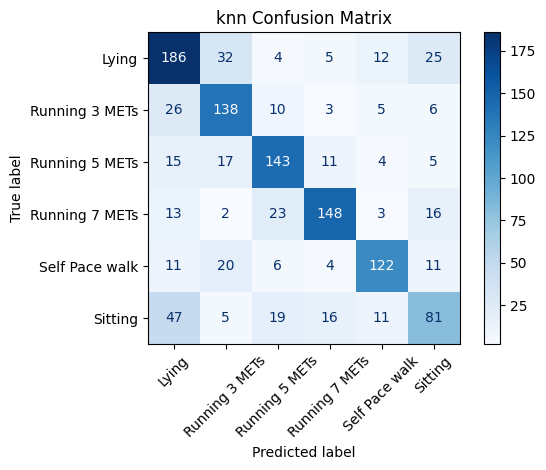

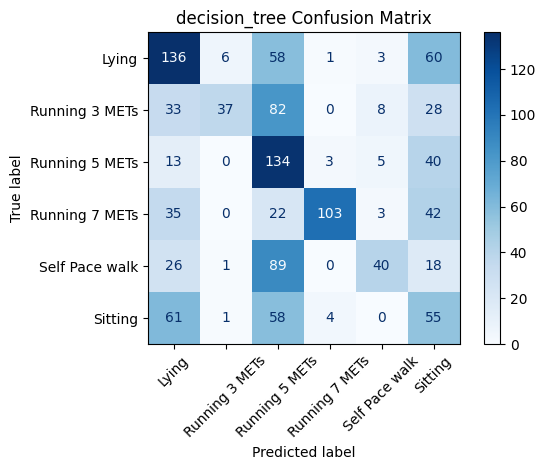

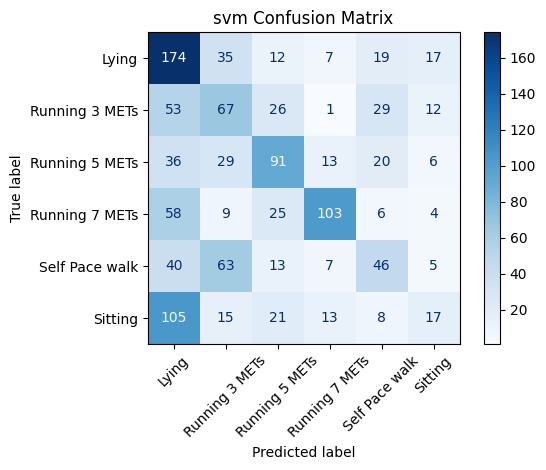

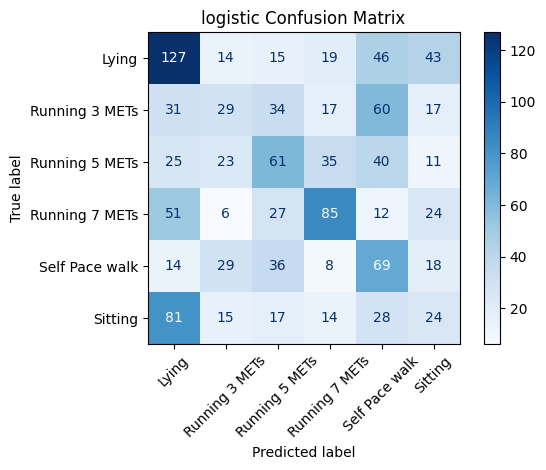

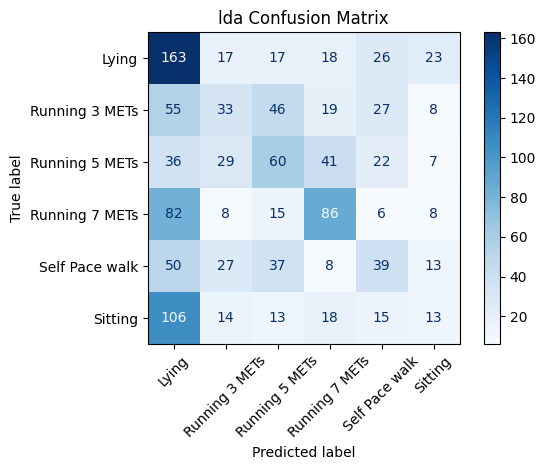

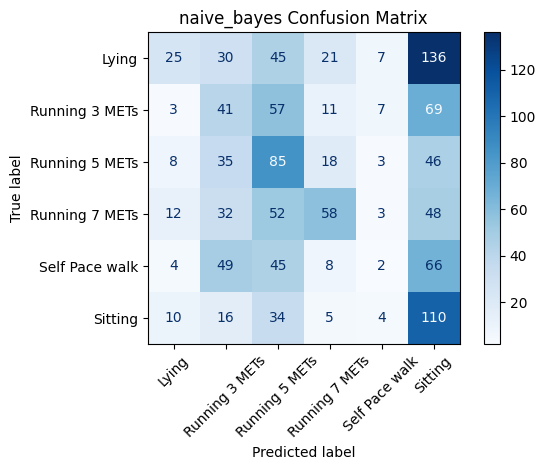

In [32]:
for index, row in all_models_results_df.iterrows(): # for selected rows in the table
  disp = ConfusionMatrixDisplay( # create a confusion matrix display
      confusion_matrix = row["test_confusion_matrix"], # grab the test confusion matrix
      display_labels = row["model"].classes_ # display class labels
  )

  disp.plot(cmap='Blues', xticks_rotation=45) # shading and format

  plt.title(f"{row["name"]} Confusion Matrix") # create a confusion matrix
  plt.tight_layout()
  plt.show() # show results for baseline matrices

**Baseline ROC Curves**
- knn heavily overfits
- svm and decision tree are our 2 best stable models

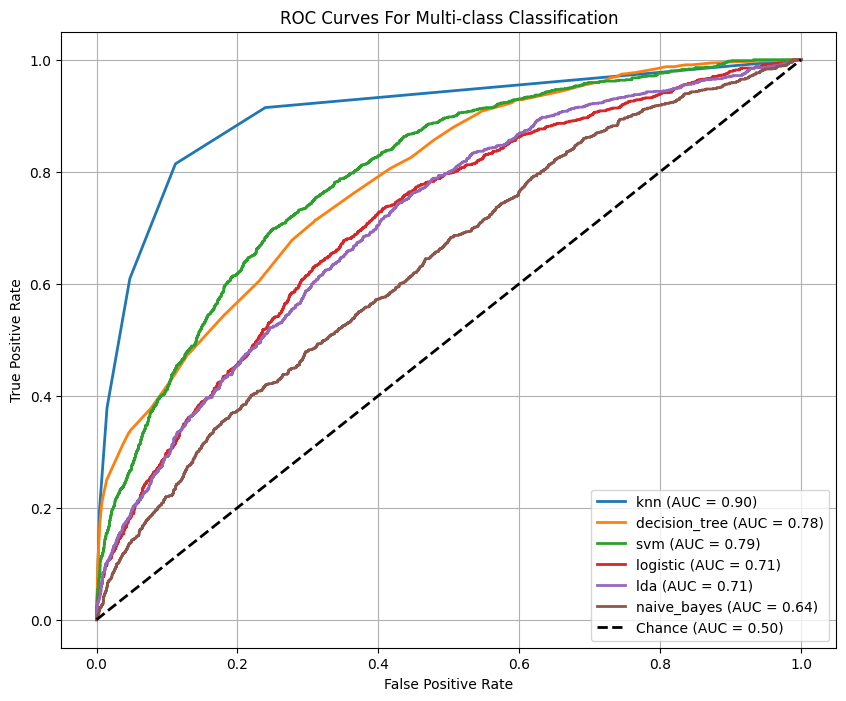

In [33]:
# import binary labels processor and roc_auc plots
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc

# binarize the target variable for multi-class ROC AUC
lb = LabelBinarizer()
y_train_bin = lb.fit_transform(np.ravel(y_train))
y_test_bin = lb.transform(np.ravel(y_test))
class_labels = lb.classes_

roc_models = {} # create dictionary for roc_aucs

for index, row in all_models_results_df.iterrows(): # for each row in the table
  roc_models[row["name"]] = row["model"] # grab the model row and add it into models

plt.figure(figsize=(10, 8)) # create a base grid

auc_scores = {} # create another dictionary for roc_auc scores

for name, model_pipeline in roc_models.items(): # for each model
    # fit the model pipeline with the original (non-binarized) y_train for multi-class models
    model_pipeline.fit(X_train, np.ravel(y_train))

    # predict probabilities for the test set
    y_score = model_pipeline.predict_proba(X_test)

    # compute micro-average ROC curves and ROC areas
    fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro);
    auc_scores[name] = roc_auc_micro

    # add this label to the legend
    plt.plot(fpr_micro, tpr_micro, label=f'{name} (AUC = {roc_auc_micro:.2f})', lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance (AUC = 0.50)') # plot dashed random line
plt.xlabel('False Positive Rate') # label x-axis
plt.ylabel('True Positive Rate') # label y-axis
plt.title('ROC Curves For Multi-class Classification') # create title
plt.legend(loc='lower right') # place legend in the lower right hand corner
plt.grid(True) # show grid
plt.show() # show roc_auc curves

In [34]:
all_models_results_df # show final table results one last time for direct comparison

,name,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_kappa,test_kappa,train_roc_auc,test_roc_auc,train_confusion_matrix,test_confusion_matrix
1,knn,"(ColumnTransformer(remainder='passthrough',\n ...",0.805936,0.678838,0.806885,0.680648,0.805936,0.678838,0.765843,0.611943,0.973559,0.899465,"[[868, 52, 12, 19, 34, 70], [64, 623, 13, 9, 3...","[[186, 32, 4, 5, 12, 25], [26, 138, 10, 3, 5, ..."
4,decision_tree,"(ColumnTransformer(remainder='passthrough',\n ...",0.467414,0.419087,0.607367,0.564625,0.467414,0.419087,0.355434,0.297321,0.799813,0.768660,"[[588, 9, 235, 6, 16, 201], [110, 206, 339, 2,...","[[136, 6, 58, 1, 3, 60], [33, 37, 82, 0, 8, 28..."
5,svm,"(ColumnTransformer(remainder='passthrough',\n ...",0.479660,0.413278,0.514191,0.423064,0.479660,0.413278,0.364938,0.283273,0.824443,0.789446,"[[769, 118, 39, 18, 84, 27], [180, 338, 111, 1...","[[174, 35, 12, 7, 19, 17], [53, 67, 26, 1, 29,..."
0,logistic,"(ColumnTransformer(remainder='passthrough',\n ...",0.347240,0.327801,0.346544,0.321865,0.347240,0.327801,0.211436,0.187254,0.718424,0.708960,"[[538, 82, 33, 93, 175, 134], [108, 193, 128, ...","[[127, 14, 15, 19, 46, 43], [31, 29, 34, 17, 6..."
3,lda,"(ColumnTransformer(remainder='passthrough',\n ...",0.337692,0.326971,0.322554,0.309993,0.337692,0.326971,0.190391,0.176067,0.710799,0.703563,"[[667, 77, 34, 80, 116, 81], [179, 188, 164, 7...","[[163, 17, 17, 18, 26, 23], [55, 33, 46, 19, 2..."
2,naive_bayes,"(ColumnTransformer(remainder='passthrough',\n ...",0.274803,0.266390,0.318684,0.290163,0.274803,0.266390,0.137628,0.127676,0.671409,0.668101,"[[115, 114, 148, 79, 26, 573], [24, 232, 225, ...","[[25, 30, 45, 21, 7, 136], [3, 41, 57, 11, 7, ..."


## **Stage 4: Final Model Tuning**
- Hyperparameters applied to SVM and Decision Tree to achieve best results


### Step 1: Fine Tuning SVM/SVC
- import grid search
- define hyperparameter lists
- log and print final results

In [35]:
# import necessary modules for efficient grid search strategies
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

In [36]:
# using GridSearchCV for effectively tuning parameters
c_param_list = [0.1, 1, 10, 100] # assign l2 regularization param list for svc
gamma_param_list = [1, 0.1, 0.01, 0.001] # assign decision boundary outlier detection

# assign these in a parameter dictionary
parameters = {
    'kernel' : ['rbf', 'sigmoid'], # focus on rbf and sigmoid kernels for classification and common use
    'C' : c_param_list,
    'gamma' : gamma_param_list
}

svc = SVC(random_state=model_random_state, probability = True) # define svc model with random state 42

svcTuning = GridSearchCV(svc, parameters, cv=5, n_jobs = -1, verbose=3)
# use grid search for optimal tuning
# cross validation of 5 (data is split 80/20 and tested 5 times for fair accuracy)
# uses all available cpus and debugging techniques

svcTuning.fit(X_train, np.ravel(y_train)) # fit tuning to training data


Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'sigmoid']},
             verbose=3)

In [37]:
svcTuning.cv_results_ # print results during training for proper documentation and logging

{'mean_fit_time': array([12.17738547,  5.24613023, 12.99610868,  5.34116993, 10.59323602,
         5.41652946,  9.06500983,  5.18298883, 12.16512165,  5.41529121,
        13.75403061,  5.22750311, 10.72202082,  5.50579243,  7.00299497,
         5.26047254, 13.30949035,  5.52301702, 13.30310898,  5.18969016,
        10.71017199,  5.40450482,  7.02566357,  5.21563544, 12.29236393,
         5.4840014 , 13.19058018,  5.19522338, 10.67721281,  5.24285579,
         6.38671951,  4.39916058]),
 'std_fit_time': array([0.7573223 , 0.06146579, 1.17180721, 0.12009072, 0.57737798,
        0.14789802, 1.00544495, 0.0598602 , 0.64806859, 0.13897422,
        1.43174645, 0.0571552 , 0.45484982, 0.14551188, 0.31039059,
        0.06921831, 1.5338189 , 0.0533292 , 0.74512545, 0.09735891,
        0.18000511, 0.05665401, 0.42762923, 0.09678598, 0.09941489,
        0.15582837, 0.63595729, 0.0838923 , 0.57713002, 0.15484218,
        0.30228445, 0.52433413]),
 'mean_score_time': array([0.66085019, 0.15901265, 

In [38]:
bestSVC = svcTuning.best_estimator_ # assign bestSVC model as bestSVC

In [39]:
bestSVC

SVC(C=100, gamma=0.001, probability=True, random_state=42)

In [56]:
bestSVC.get_params() # return parameters from grid search

{'C': 100,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 0.001,
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': True,
 'random_state': 42,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

### **Best Parameters:**
#### Best SVC - kernal = rbf, C = 100, gamma = 0.001

- next predict class labels with the new refined SVC model

In [40]:
y_pred_train = bestSVC.predict(X_train) # predict class labels for training data
y_pred_test = bestSVC.predict(X_test) # predict class labels for testing data

y_pred_train_prob = bestSVC.predict_proba(X_train) # calculate probability estimates for training
y_pred_test_prob = bestSVC.predict_proba(X_test) # calculate probability estimates for testing

In [41]:

train_accuracy = metrics.accuracy_score(y_train, y_pred_train) # get training accuracy
test_accuracy = metrics.accuracy_score(y_test, y_pred_test) # get testing accuracy

train_recall = metrics.recall_score(y_train, y_pred_train, average='weighted') # get training recall by class averages
test_recall = metrics.recall_score(y_test, y_pred_test, average='weighted') # get testing recall by class averages

train_precision = metrics.precision_score(y_train, y_pred_train, average='weighted') # get training precision by class averages
test_precision = metrics.precision_score(y_test, y_pred_test, average='weighted') # get testing precision by class averages

train_kappa = metrics.cohen_kappa_score(y_train , y_pred_train) # get training kappa
test_kappa = metrics.cohen_kappa_score(y_test, y_pred_test) # get testing kappa

train_roc_auc = metrics.roc_auc_score(np.ravel(y_train), y_pred_train_prob, average="weighted", multi_class="ovr") # get training roc_auc
test_roc_auc = metrics.roc_auc_score(np.ravel(y_test), y_pred_test_prob, average="weighted", multi_class="ovr") # get testing roc_auc

# fit results in a dictionary
results = {
    'train_accuracy' : train_accuracy,
    'test_accuracy' : test_accuracy,
    'train_precision' : train_precision,
    'test_precision' : test_precision,
    'train_recall' : train_recall,
    'test_recall' : test_recall,
    'train_kappa' : train_kappa,
    'test_kappa' : test_kappa,
    'train_roc_auc' : train_roc_auc,
    'test_roc_auc' : test_roc_auc
}

final_svc_results = pd.DataFrame([results]) # construct data frame table


In [42]:
final_svc_results # show final results table for svm/svc

,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_kappa,test_kappa,train_roc_auc,test_roc_auc
0,0.956413,0.699585,0.956578,0.699666,0.956413,0.699585,0.947481,0.637467,0.996029,0.920558


### Step 2: Visualizing Final Influences of SVC
- show confusion matrix
- show ROC_AUC curves by class
- show feature importance

<Figure size 1000x800 with 0 Axes>

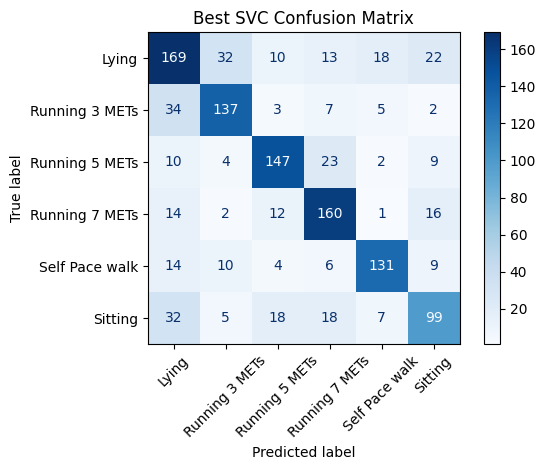

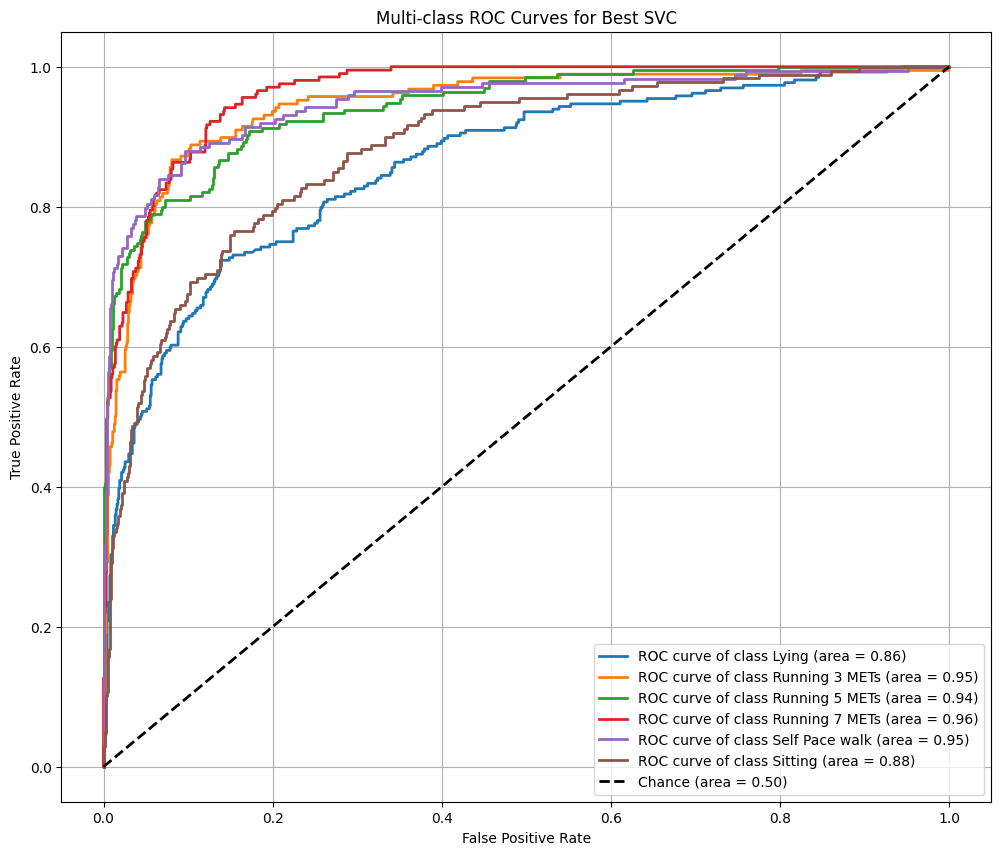

In [43]:
# Visualize SVC Results

pred_test_svc = bestSVC.predict(X_test) # get test predictions
pred_test_prob_svc = bestSVC.predict_proba(X_test) # calculate test probability estimates

# build final confusion matrix
cm_svc = confusion_matrix(y_test, pred_test_svc, labels=bestSVC.classes_)
disp_svc = ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=bestSVC.classes_)

# plot final confusion matrix
plt.figure(figsize=(10, 8))
disp_svc.plot(cmap='Blues', xticks_rotation=45)
plt.title('Best SVC Confusion Matrix')
plt.tight_layout()
plt.show()

from sklearn.preprocessing import label_binarize # import binarization for model classes

# binarize the target variable for multi-class ROC AUC
class_labels = bestSVC.classes_
test_bin = label_binarize(y_test, classes=class_labels)

# label probability estimates as scores
y_score = pred_test_prob_svc

plt.figure(figsize=(12, 10))

# plot ROC curve for each class (One vs. Rest)
fpr_svc = dict()
tpr_svc = dict()
roc_auc = dict()

# slight Gemini Ai help here
# for formatting of the for loop only
for i in range(len(class_labels)): # for all class labels
    fpr_svc[i], tpr_svc[i], _ = roc_curve(test_bin[:, i], y_score[:, i]) # calculate the roc curve
    roc_auc[i] = auc(fpr_svc[i], tpr_svc[i])
    plt.plot(fpr_svc[i], tpr_svc[i], lw=2, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance (area = 0.50)') # plot details
plt.xlabel('False Positive Rate') # label x-axis
plt.ylabel('True Positive Rate') # label y-axis
plt.title('Multi-class ROC Curves for Best SVC') # show title
plt.legend(loc='lower right') # plot legend
plt.grid(True)
plt.show()

In [44]:
# calculate feature importance
from sklearn.inspection import permutation_importance # since svc doesn't have an importance parameter, we need permutation importance

# permutation importance for SVC
perm_importance = permutation_importance(bestSVC, X_test, np.ravel(y_test), n_repeats=5, random_state=42, n_jobs=-1)
# use best model with testing data, random state 42, and available cpu cores with valid cycles

# grab means as svc_importances and sort values descending order
svc_importance = perm_importance.importances_mean
svc_features = pd.DataFrame({'Feature': X_test.columns, 'Importance': svc_importance}) # organize features into a dataframe
svc_features = svc_features.sort_values(by='Importance', ascending=False) # sort values by highest importance

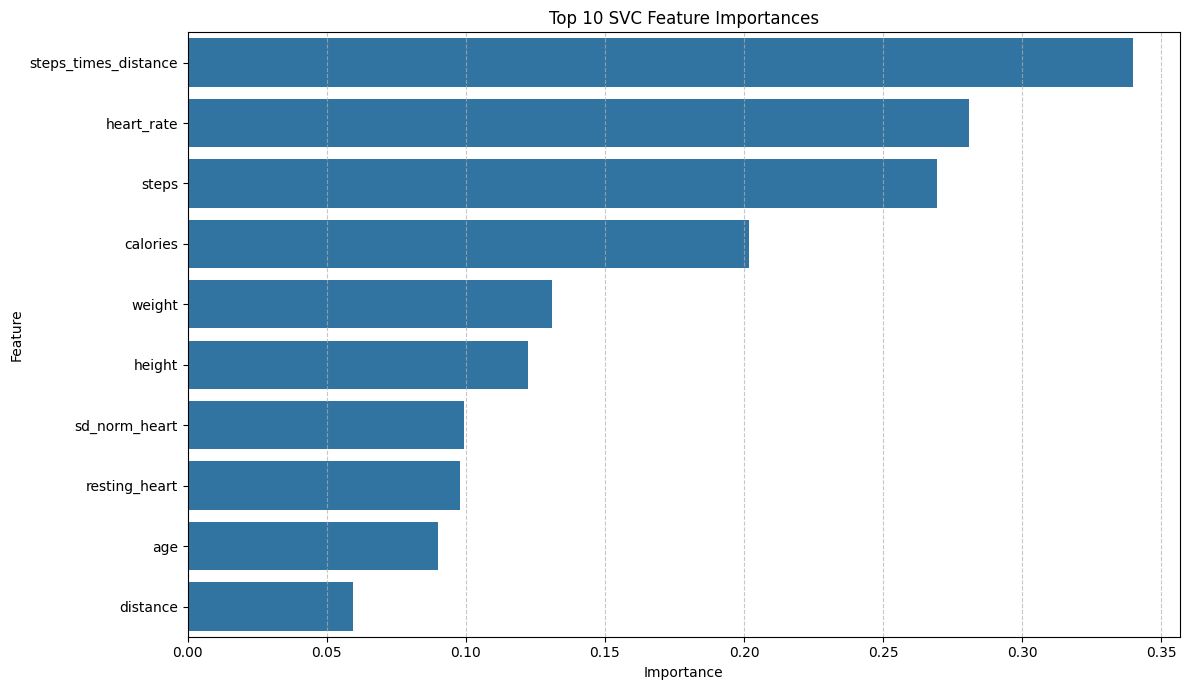

In [45]:
# bar chart for SVC Feature Importances (Permutation Importance)
plt.figure(figsize=(12, 7)) # plot figure size
sns.barplot(x='Importance', y='Feature', data=svc_features.head(10)) # grab top 10 feature importances
plt.title('Top 10 SVC Feature Importances') # plot title
plt.xlabel('Importance') # label x-axis
plt.ylabel('Feature') # label y-axis
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Step 3: Fine Tuning Decision Tree
- define hyperparameter lists
- log and print final results

In [46]:
parameters = { # define decision tree parameters
    'max_depth' : [10, 15, 20, 25, 30, None], # max depth in typical ranges
    'min_samples_split' : [2, 5, 10], # min samples
    'min_samples_leaf' : [1, 2, 4] # leaf samples
}

decision_tree = DecisionTreeClassifier(random_state=model_random_state) # define decision tree model

decision_tree_tuning = GridSearchCV(decision_tree, parameters, cv=5, n_jobs=-1, verbose=3)
# use grid search for optimal tuning
# cross validation of 5 (data is split 80/20 and tested 5 times for valid accuracy)
# uses all available cpus and debugging techniques

decision_tree_tuning.fit(X_train, np.ravel(y_train)) # fit tuned model to training data


Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 15, 20, 25, 30, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             verbose=3)

In [47]:
decision_tree_tuning.cv_results_ # print tuning activity for proper documentation and logging

{'mean_fit_time': array([0.06571069, 0.06660938, 0.06577444, 0.06614609, 0.06659513,
        0.06481361, 0.06504459, 0.06529288, 0.06445651, 0.08149304,
        0.08151612, 0.08270421, 0.08219247, 0.08275414, 0.07879295,
        0.0767611 , 0.07688689, 0.07770433, 0.08583078, 0.08530049,
        0.0829246 , 0.086233  , 0.08337698, 0.0816144 , 0.07995825,
        0.0791101 , 0.07871461, 0.08656778, 0.08612714, 0.08350382,
        0.08402977, 0.08361559, 0.08198843, 0.07977681, 0.07995381,
        0.07889075, 0.0868928 , 0.08586378, 0.08591452, 0.08404994,
        0.08629017, 0.08510685, 0.0793963 , 0.0804769 , 0.07973695,
        0.08597174, 0.08561497, 0.08359871, 0.08360224, 0.08400073,
        0.08177066, 0.07937431, 0.07859669, 0.07392077]),
 'std_fit_time': array([0.00210801, 0.00097721, 0.00192343, 0.00144171, 0.00133892,
        0.00228023, 0.00127402, 0.00176603, 0.00180086, 0.00363119,
        0.00389261, 0.0041221 , 0.00411082, 0.00627573, 0.00067503,
        0.0007112 , 0.001

In [48]:
best_decision_tree = decision_tree_tuning.best_estimator_ # define best decision tree

best_decision_tree # print out ideal model parameters

DecisionTreeClassifier(max_depth=30, random_state=42)

In [49]:
best_decision_tree.get_params() # return parameters from grid search

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 30,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

### **Best Parameters:**
#### Best Decision Tree - max_depth = 30, min_samples_leaf: 1, min_samples_split: 2

- next predict class labels with the new refined SVC model

In [50]:
y_pred_train = best_decision_tree.predict(X_train) # predict class labels in training data
y_pred_test = best_decision_tree.predict(X_test) # predict class labels in testing data

y_pred_train_prob = best_decision_tree.predict_proba(X_train) # calculate probability estiamtes in training
y_pred_test_prob = best_decision_tree.predict_proba(X_test) # calculate probability estimates in testing

In [51]:

train_accuracy = metrics.accuracy_score(y_train, y_pred_train) # get training accuracy
test_accuracy = metrics.accuracy_score(y_test, y_pred_test) # get testing accuracy

train_recall = metrics.recall_score(y_train, y_pred_train, average='weighted') # get training recall by classes
test_recall = metrics.recall_score(y_test, y_pred_test, average='weighted') # get testing recall by classses

train_precision = metrics.precision_score(y_train, y_pred_train, average='weighted') # get training precision by classes
test_precision = metrics.precision_score(y_test, y_pred_test, average='weighted') # get testing precision by classes

train_kappa = metrics.cohen_kappa_score(y_train , y_pred_train) # get training kappa
test_kappa = metrics.cohen_kappa_score(y_test, y_pred_test) # get testing kappa

train_roc_auc = metrics.roc_auc_score(np.ravel(y_train), y_pred_train_prob, average="weighted", multi_class="ovr") # get training roc_auc by classes
test_roc_auc = metrics.roc_auc_score(np.ravel(y_test), y_pred_test_prob, average="weighted", multi_class="ovr") # get testing roc_auc by classes

results = { # define results in a dictionary
    'train_accuracy' : train_accuracy,
    'test_accuracy' : test_accuracy,
    'train_precision' : train_precision,
    'test_precision' : test_precision,
    'train_recall' : train_recall,
    'test_recall' : test_recall,
    'train_kappa' : train_kappa,
    'test_kappa' : test_kappa,
    'train_roc_auc' : train_roc_auc,
    'test_roc_auc' : test_roc_auc
}


final_decision_tree_results = pd.DataFrame([results]) # create dataframe for final results


In [52]:
final_decision_tree_results # print final results for best decision tree

,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_kappa,test_kappa,train_roc_auc,test_roc_auc
0,1.0,0.759336,1.0,0.762825,1.0,0.759336,1.0,0.71024,1.0,0.855086


### Step 4: Visualizing Final Influences of Decision Tree
- show confusion matrix
- show ROC_AUC curves by class
- show feature importance

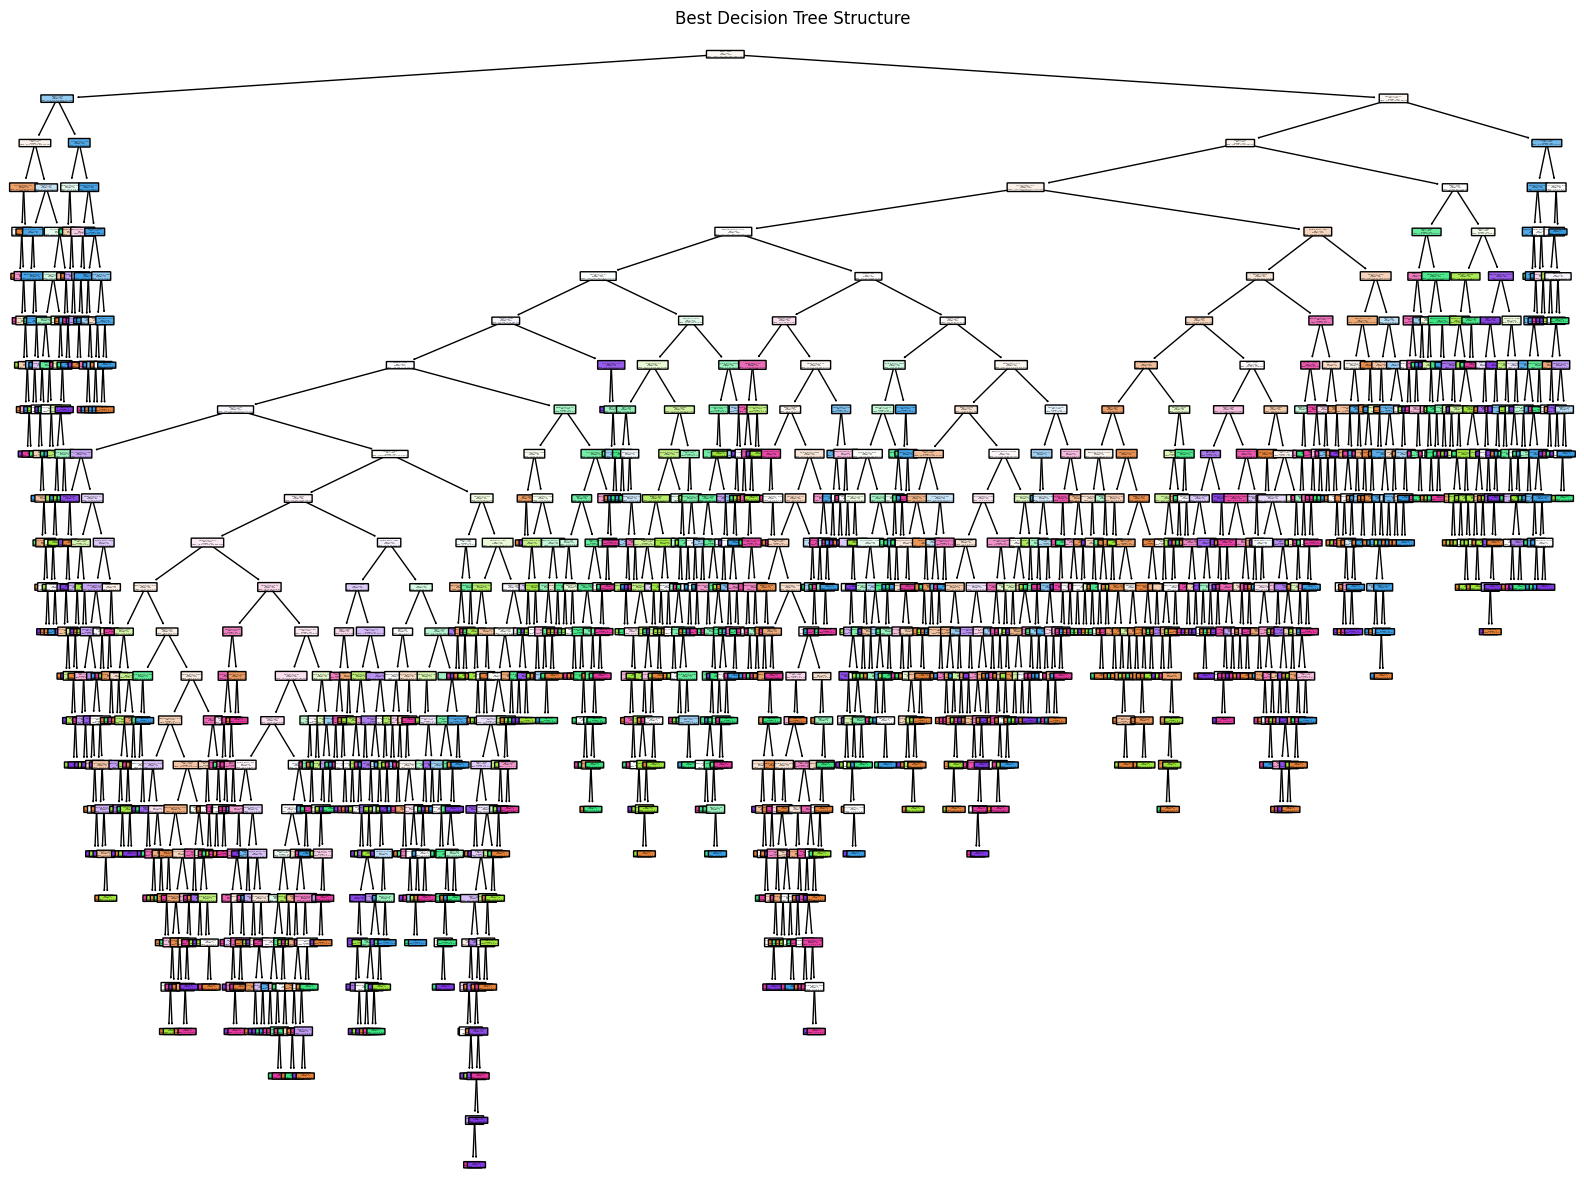

<Figure size 1000x800 with 0 Axes>

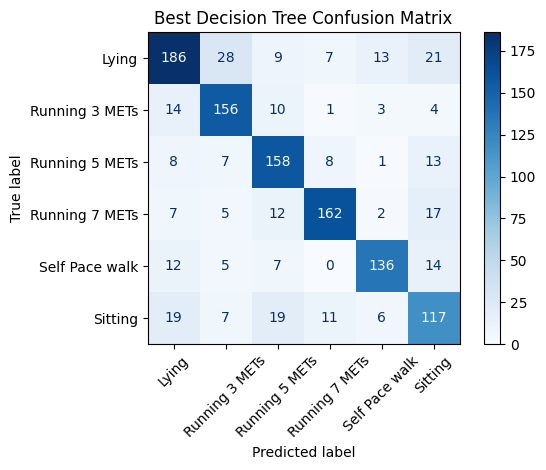

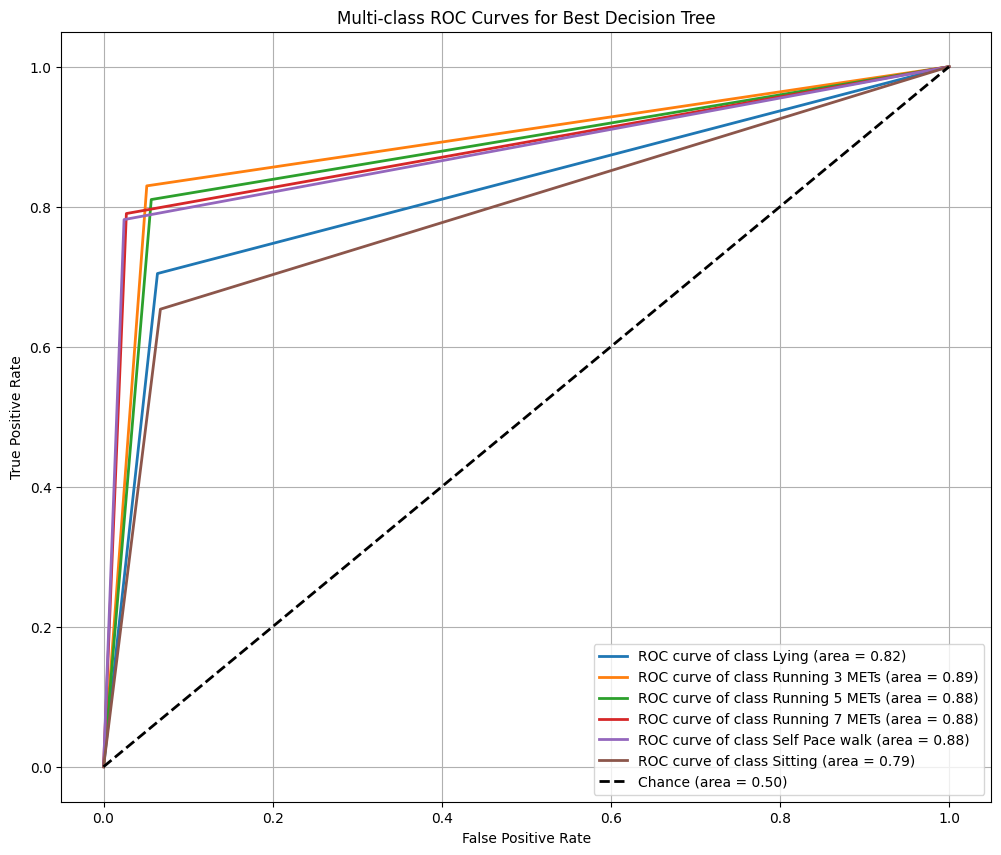

In [53]:
from sklearn.tree import plot_tree # import decision tree visualization

# plot decision tree
plt.figure(figsize=(20, 15)) # use optimal sizing
plot_tree(best_decision_tree, filled=True, feature_names=X_train.columns.tolist(), class_names=best_decision_tree.classes_.tolist(), rounded=True)
# grab columns and classes with rounded values
plt.title('Best Decision Tree Structure') # show title
plt.show() # to see decision tree complexity

# build best decision tree confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_test, labels=best_decision_tree.classes_)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=best_decision_tree.classes_)

# plot final confusion matrix
plt.figure(figsize=(10, 8))
disp_dt.plot(cmap='Blues', xticks_rotation=45)
plt.title('Best Decision Tree Confusion Matrix')
plt.tight_layout()
plt.show()

# binarize the target variable for decision tree multi-class ROC AUC
classes_dt = best_decision_tree.classes_
test_bin_dt = label_binarize(y_test, classes=classes_dt)

# predict probabilities for the test set using the best_decision_tree
y_score_dt = best_decision_tree.predict_proba(X_test)

plt.figure(figsize=(12, 10)) # plot shape

# plot ROC curve for each class (One vs. Rest)
fpr_dt = dict()
tpr_dt = dict()
roc_auc_dt = dict()

# slight Gemini Ai help here
# for formatting of the for loop only
for i in range(len(classes_dt)): # for all class labels
    fpr_dt[i], tpr_dt[i], _ = roc_curve(test_bin_dt[:, i], y_score_dt[:, i]) # calculate the roc curve
    roc_auc_dt[i] = auc(fpr_dt[i], tpr_dt[i])
    plt.plot(fpr_dt[i], tpr_dt[i], lw=2, label=f'ROC curve of class {classes_dt[i]} (area = {roc_auc_dt[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance (area = 0.50)')
plt.xlabel('False Positive Rate') # label x-axis
plt.ylabel('True Positive Rate') # label y-axis
plt.title('Multi-class ROC Curves for Best Decision Tree') # plot title
plt.legend(loc='lower right') # plot legend
plt.grid(True)
plt.show()


In [54]:
# feature importance for decision tree
dt_importances = best_decision_tree.feature_importances_ # get feature importances parameter
dt_features = pd.DataFrame({'Feature': X.columns, 'Importance': dt_importances}) # organize features into a dataframe
dt_features = dt_features.sort_values(by='Importance', ascending=False) # sort values by highest importance

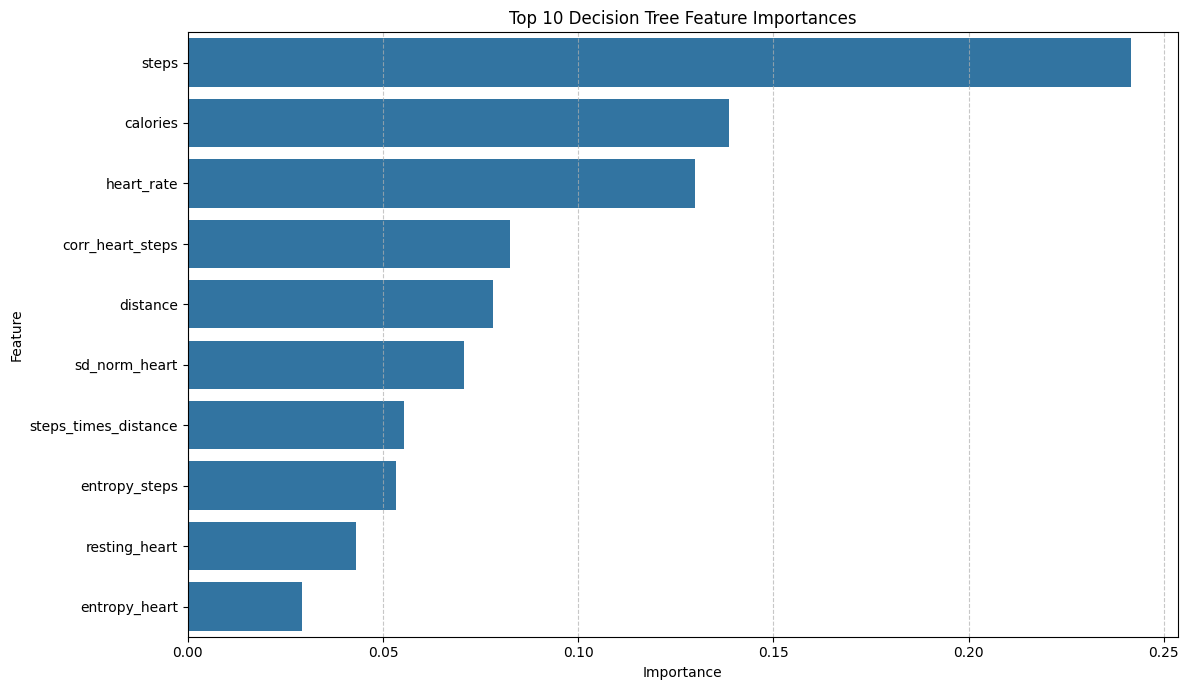

In [55]:
# bar chart for Decision Tree Feature Importances
plt.figure(figsize=(12, 7)) # plot figure size
sns.barplot(x='Importance', y='Feature', data=dt_features.head(10)) # grab top 10 important features
plt.title('Top 10 Decision Tree Feature Importances') # plot title
plt.xlabel('Importance') # label x-axis
plt.ylabel('Feature') # label y-axis
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Key Findings:**

1. Running and walking activities were classified most accurately.
2. Sitting and lying activities were confused across all models.
3. Decision trees achieved the strongest performances overall.
4. Tuning hyperparameters through grid search proved beneficial for testing metrics, however, resulted in overfitting.
5. Decision trees were identified as the best classification models for physical activities.

# **Best Physical Activity Classifiers:**
**(found as the top 10 in both models)**

- Steps_Times_Distance
- Heart Rate
- Steps
- Calories
- Distance
- Sd_Norm_Heart
- Resting_Heart

**Combinations of body durability, motion indicators, and exercise outcomes**